In [7]:
# 通用数据处理函数
import pandas as pd
import re


def default_col_rename(col):
    base = col.split(' [')[0].strip().lower()
    base = re.sub(r'[^0-9a-zA-Z]+', '_', base)
    return re.sub(r'_+', '_', base).strip('_')


def clean_and_format_df(
    df,
    date_col_start='Start date',
    date_col_end='End date',
    value_col_start=2,
    time_zone='Europe/Berlin',
    freq_minutes=15,
    col_rename_rule=None,
    utc_col='start_date_utc',
    datetime_format='%b %d, %Y %I:%M %p',
    verbose=True,
):
    """清洗单个 DataFrame：时间列、数值列、列名、End date 修复、UTC 时间列、断层检查。"""
    df = df.copy()

    # 1. 时间列
    df[date_col_start] = pd.to_datetime(df[date_col_start], format=datetime_format)
    df[date_col_end] = pd.to_datetime(df[date_col_end], format=datetime_format)

    # 2. 数值列：先统一按字符串清洗，再转数值
    value_columns = df.columns[value_col_start:]
    for col in value_columns:
        cleaned = (
            df[col]
            .astype(str)
            .str.strip()
            .replace({'-': None, 'nan': None, 'None': None})
            .str.replace(',', '', regex=False)
        )
        df[col] = pd.to_numeric(cleaned, errors='coerce')

    # 3. 列名重命名
    if col_rename_rule is not None:
        renamed_columns = {col: col_rename_rule(col) for col in value_columns}
        df.rename(columns=renamed_columns, inplace=True)

    # 4. 修复 End date（统一按固定频率推导，避免 DST 边界问题）
    df[date_col_end] = df[date_col_start] + pd.Timedelta(minutes=freq_minutes)

    # 5. 增加 UTC 时间戳
    df[utc_col] = df[date_col_start].dt.tz_localize(
        time_zone,
        ambiguous='infer',
        nonexistent='shift_forward',
    ).dt.tz_convert('UTC')

    # 6. 检查断层
    time_diffs = df[date_col_start].diff().dropna()
    gaps = time_diffs[time_diffs != pd.Timedelta(minutes=freq_minutes)]

    if verbose:
        print(f'数据形状: {df.shape}')
        print(f'数值列数量: {len(df.columns[value_col_start:])}')
        if gaps.empty:
            print('时间戳连续，无断层 ✓')
        else:
            print(f'警告：发现 {len(gaps)} 处时间断层！')
            print(gaps)

    return df


def load_and_clean_csv(
    file_path,
    sep=';',
    **kwargs,
):
    """从 CSV 读取后直接调用 clean_and_format_df。统一按字符串读取，避免 pandas 提前误判类型。"""
    raw_df = pd.read_csv(file_path, sep=sep, dtype=str)
    return clean_and_format_df(raw_df, **kwargs)


In [ ]:
# 示例：直接处理价格表 CSV
df_prices = load_and_clean_csv(
    '../Data/Day-ahead_prices_201901010000_202603240000_Quarterhour.csv',
    col_rename_rule=default_col_rename,
)

print(df_prices[['Start date', 'End date', 'start_date_utc']].head())
print(df_prices.columns.tolist())

# 注意开始时间和结束时间：  2019-01-01 00:00:00  -> 2018-12-31 23:00:00+00:00

/tmp/ipykernel_2608/2680831655.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[date_col_start] = pd.to_datetime(df[date_col_start])
/tmp/ipykernel_2608/2680831655.py:28: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[date_col_end] = pd.to_datetime(df[date_col_end])


数据形状: (253344, 20)
数值列数量: 18
警告：发现 14 处时间断层！
8552       0 days 01:15:00
28712    -1 days +23:15:00
43496      0 days 01:15:00
63656    -1 days +23:15:00
78440      0 days 01:15:00
99272    -1 days +23:15:00
113384     0 days 01:15:00
134216   -1 days +23:15:00
148328     0 days 01:15:00
169160   -1 days +23:15:00
183944     0 days 01:15:00
204104   -1 days +23:15:00
218888     0 days 01:15:00
239048   -1 days +23:15:00
Name: Start date, dtype: timedelta64[us]
           Start date            End date            start_date_utc
0 2019-01-01 00:00:00 2019-01-01 00:15:00 2018-12-31 23:00:00+00:00
1 2019-01-01 00:15:00 2019-01-01 00:30:00 2018-12-31 23:15:00+00:00
2 2019-01-01 00:30:00 2019-01-01 00:45:00 2018-12-31 23:30:00+00:00
3 2019-01-01 00:45:00 2019-01-01 01:00:00 2018-12-31 23:45:00+00:00
4 2019-01-01 01:00:00 2019-01-01 01:15:00 2019-01-01 00:00:00+00:00
['Start date', 'End date', 'germany_luxembourg', 'de_lu_neighbours', 'belgium', 'denmark_1', 'denmark_2', 'france', 'netherlands

In [20]:
print('df_prices:', df_prices.shape)

print('\ndf_prices 关键列缺失值：')
print(df_prices[['germany_luxembourg']].isna().sum())

print('\ndf_prices 时间列预览：')
print(df_prices[['Start date', 'End date', 'start_date_utc']].head(3))

df_prices: (253344, 20)

df_prices 关键列缺失值：
germany_luxembourg    0
dtype: int64

df_prices 时间列预览：
           Start date            End date            start_date_utc
0 2019-01-01 00:00:00 2019-01-01 00:15:00 2018-12-31 23:00:00+00:00
1 2019-01-01 00:15:00 2019-01-01 00:30:00 2018-12-31 23:15:00+00:00
2 2019-01-01 00:30:00 2019-01-01 00:45:00 2018-12-31 23:30:00+00:00


In [8]:
# 同时加载并清洗发电表、用电表
base_data_dir = '../Data'

df_gen, df_cons = (
    load_and_clean_csv(
        f'{base_data_dir}/Actual_generation_201901010000_202603240000_Quarterhour.csv',
        col_rename_rule=default_col_rename,
        verbose=False,
    ),
    load_and_clean_csv(
        f'{base_data_dir}/Actual_consumption_201901010000_202603240000_Quarterhour.csv',
        col_rename_rule=default_col_rename,
        verbose=False,
    ),
)

print('df_gen:', df_gen.shape)
print('df_cons:', df_cons.shape)
print('\ndf_gen 关键列缺失值：')
print(df_gen[['wind_onshore', 'wind_offshore', 'photovoltaics']].isna().sum())
print('\ndf_cons 关键列缺失值：')
print(df_cons[['grid_load', 'residual_load']].isna().sum())
print('\ndf_gen 时间列预览：')
print(df_gen[['Start date', 'End date', 'start_date_utc']].head(3))
print('\ndf_cons 时间列预览：')
print(df_cons[['Start date', 'End date', 'start_date_utc']].head(3))

df_gen: (253344, 15)
df_cons: (253344, 7)

df_gen 关键列缺失值：
wind_onshore     58
wind_offshore    57
photovoltaics    58
dtype: int64

df_cons 关键列缺失值：
grid_load        0
residual_load    3
dtype: int64

df_gen 时间列预览：
           Start date            End date            start_date_utc
0 2019-01-01 00:00:00 2019-01-01 00:15:00 2018-12-31 23:00:00+00:00
1 2019-01-01 00:15:00 2019-01-01 00:30:00 2018-12-31 23:15:00+00:00
2 2019-01-01 00:30:00 2019-01-01 00:45:00 2018-12-31 23:30:00+00:00

df_cons 时间列预览：
           Start date            End date            start_date_utc
0 2019-01-01 00:00:00 2019-01-01 00:15:00 2018-12-31 23:00:00+00:00
1 2019-01-01 00:15:00 2019-01-01 00:30:00 2018-12-31 23:15:00+00:00
2 2019-01-01 00:30:00 2019-01-01 00:45:00 2018-12-31 23:30:00+00:00


In [9]:
# 合并发电表和用电表
df_all = pd.merge(df_gen, df_cons, on='start_date_utc', suffixes=('_gen', '_cons'))

# 手动计算剩余负荷 (根据 SMARD 官方逻辑：Load - Wind - Solar)
df_all['my_res_load'] = df_all['grid_load'] - (
    df_all['wind_onshore'] + df_all['wind_offshore'] + df_all['photovoltaics']
)

# 计算误差
df_all['error'] = df_all['residual_load'] - df_all['my_res_load']

print(f'df_all shape: {df_all.shape}')
print(f"my_res_load 缺失值: {df_all['my_res_load'].isna().sum()}")
print(f"residual_load 缺失值: {df_all['residual_load'].isna().sum()}")
print(f"平均误差: {df_all['error'].mean():.2f} MWh")

df_all shape: (253344, 23)
my_res_load 缺失值: 58
residual_load 缺失值: 3
平均误差: 0.00 MWh


In [10]:
# 计算可再生能源（仅限风光）占总负荷的比例
df_all['re_share'] = (df_all['wind_onshore'] + df_all['wind_offshore'] + df_all['photovoltaics']) / df_all['grid_load']

# 看看有没有哪一刻，风和光发的电超过了总需求？（即比例 > 100%）# 负值统计：residual_load    1413 刚好有个等于0
super_green_moments = df_all[df_all['re_share'] > 1.0]
print(f"共有 {len(super_green_moments)} 个 15 分钟时段，可再生能源发电量超过了总需求！")

共有 1412 个 15 分钟时段，可再生能源发电量超过了总需求！


In [11]:
# 把价格表并入主表，分析“绿电过剩”和“电价”的相关性
df_market = pd.merge(
    df_all,
    df_prices[['start_date_utc', 'germany_luxembourg']],
    on='start_date_utc',
    how='left'
)

df_market['is_surplus'] = df_market['re_share'] > 1.0
df_market['price_eur_mwh'] = df_market['germany_luxembourg']

corr_re_share_price = df_market[['re_share', 'price_eur_mwh']].corr().iloc[0, 1]
corr_residual_price = df_market[['residual_load', 'price_eur_mwh']].corr().iloc[0, 1]

price_summary = df_market.groupby('is_surplus')['price_eur_mwh'].agg(['count', 'mean', 'median', 'min', 'max'])
negative_price_rate = df_market.groupby('is_surplus')['price_eur_mwh'].apply(lambda series: (series < 0).mean())

print(f"re_share 与电价的相关系数: {corr_re_share_price:.3f}")
print(f"residual_load 与电价的相关系数: {corr_residual_price:.3f}")
print('\n按是否出现‘绿电超过总需求’分组的电价统计:')
print(price_summary)
print('\n各组负电价占比:')
print((negative_price_rate * 100).round(2).astype(str) + '%')

re_share 与电价的相关系数: -0.381
residual_load 与电价的相关系数: 0.403

按是否出现‘绿电超过总需求’分组的电价统计:
             count       mean  median    min     max
is_surplus                                          
False       251932  95.708626   76.38 -500.0  936.28
True          1412 -24.399943   -8.00 -500.0   39.94

各组负电价占比:
is_surplus
False     2.82%
True     86.26%
Name: price_eur_mwh, dtype: str


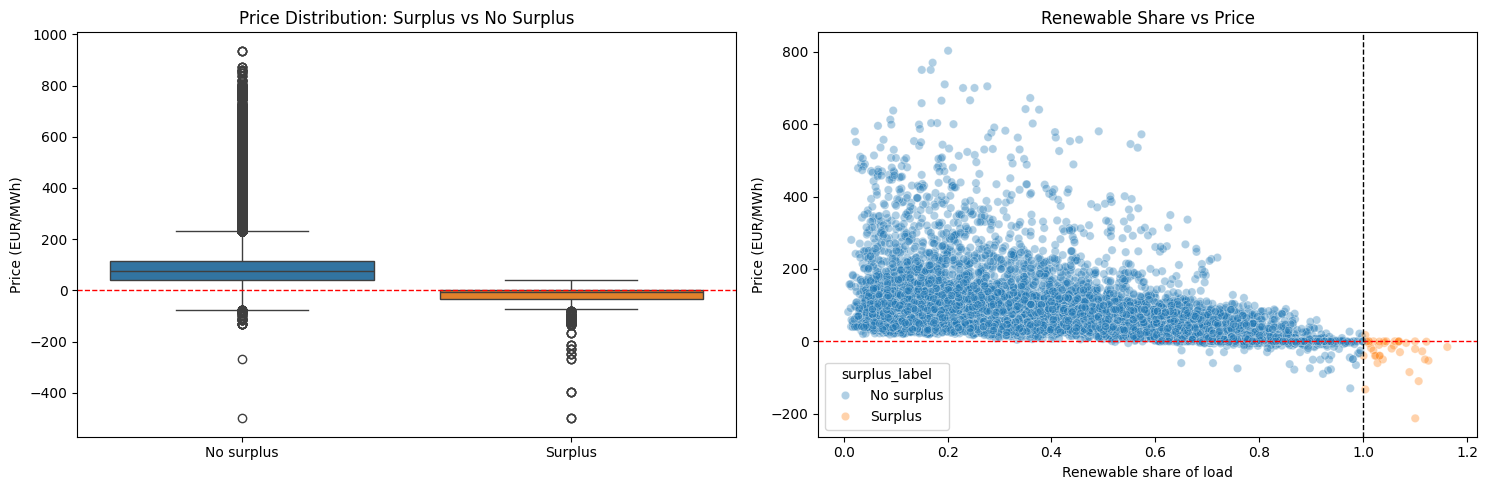

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 可视化：过剩时段 vs 非过剩时段的电价分布
plot_df = df_market[['is_surplus', 'price_eur_mwh', 're_share']].dropna().copy()
plot_df['surplus_label'] = plot_df['is_surplus'].map({False: 'No surplus', True: 'Surplus'})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=plot_df, x='surplus_label', y='price_eur_mwh', ax=axes[0], hue='surplus_label', legend=False)
axes[0].set_title('Price Distribution: Surplus vs No Surplus')
axes[0].set_xlabel('')
axes[0].set_ylabel('Price (EUR/MWh)')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)

sample_df = plot_df.sample(min(8000, len(plot_df)), random_state=42)
sns.scatterplot(data=sample_df, x='re_share', y='price_eur_mwh', hue='surplus_label', alpha=0.35, ax=axes[1])
axes[1].set_title('Renewable Share vs Price')
axes[1].set_xlabel('Renewable share of load')
axes[1].set_ylabel('Price (EUR/MWh)')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].axvline(1, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2608/523550648.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=super_green_moments, x='month', ax=ax1, palette='viridis')
/tmp/ipykernel_2608/523550648.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=super_green_moments, x='hour', ax=ax2, palette='magma')


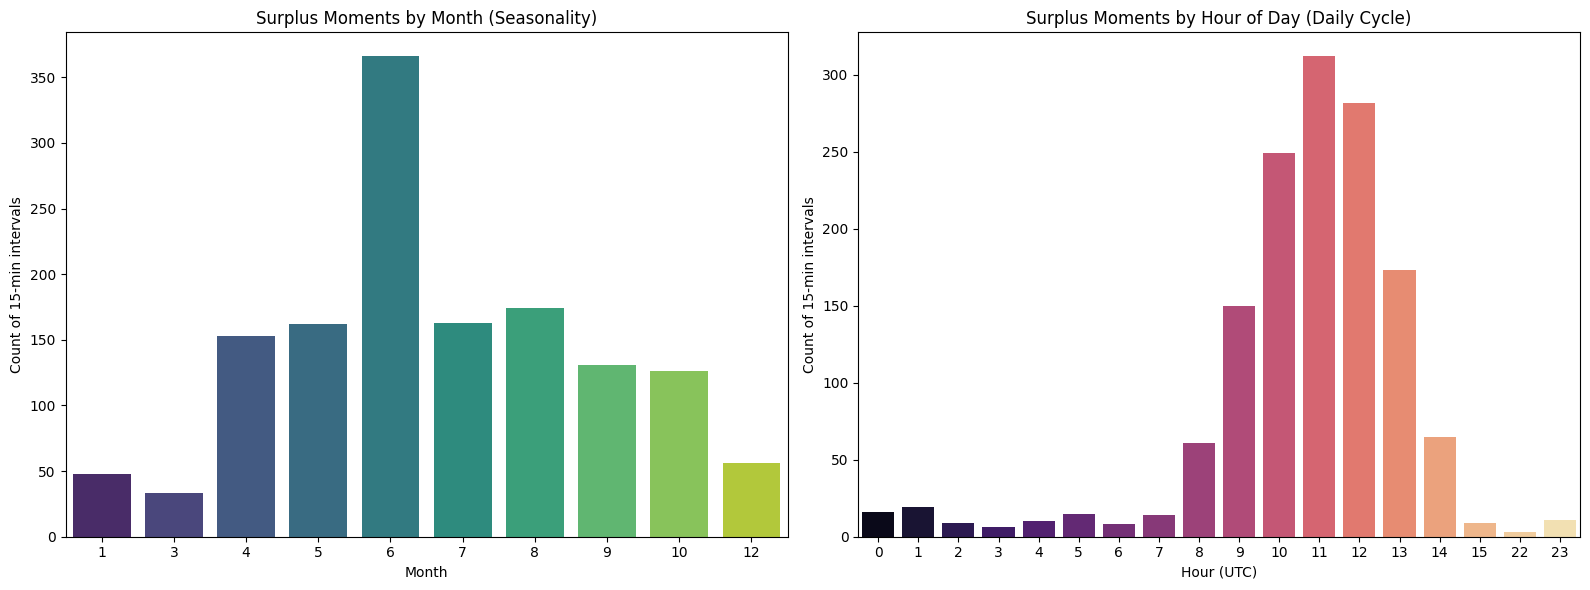

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 提取月份和小时
# 假设你的过剩时刻 DataFrame 叫 super_green_moments
super_green_moments['month'] = super_green_moments['start_date_utc'].dt.month
super_green_moments['hour'] = super_green_moments['start_date_utc'].dt.hour

# 创建一个画布，包含两个子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 图 A：按月份分布（看哪个月最容易过剩）
sns.countplot(data=super_green_moments, x='month', ax=ax1, palette='viridis')
ax1.set_title("Surplus Moments by Month (Seasonality)")
ax1.set_xlabel("Month")
ax1.set_ylabel("Count of 15-min intervals")

# 图 B：按小时分布（看一天中什么时候最绿）
sns.countplot(data=super_green_moments, x='hour', ax=ax2, palette='magma')
ax2.set_title("Surplus Moments by Hour of Day (Daily Cycle)")
ax2.set_xlabel("Hour (UTC)")
ax2.set_ylabel("Count of 15-min intervals")

plt.tight_layout()
plt.show()

#2月还有12 月都没有统计还有16到21点的记录也没有， （还有一个问题就是现在是UTC时间到dashboard还有要转换成柏林时间才合理）




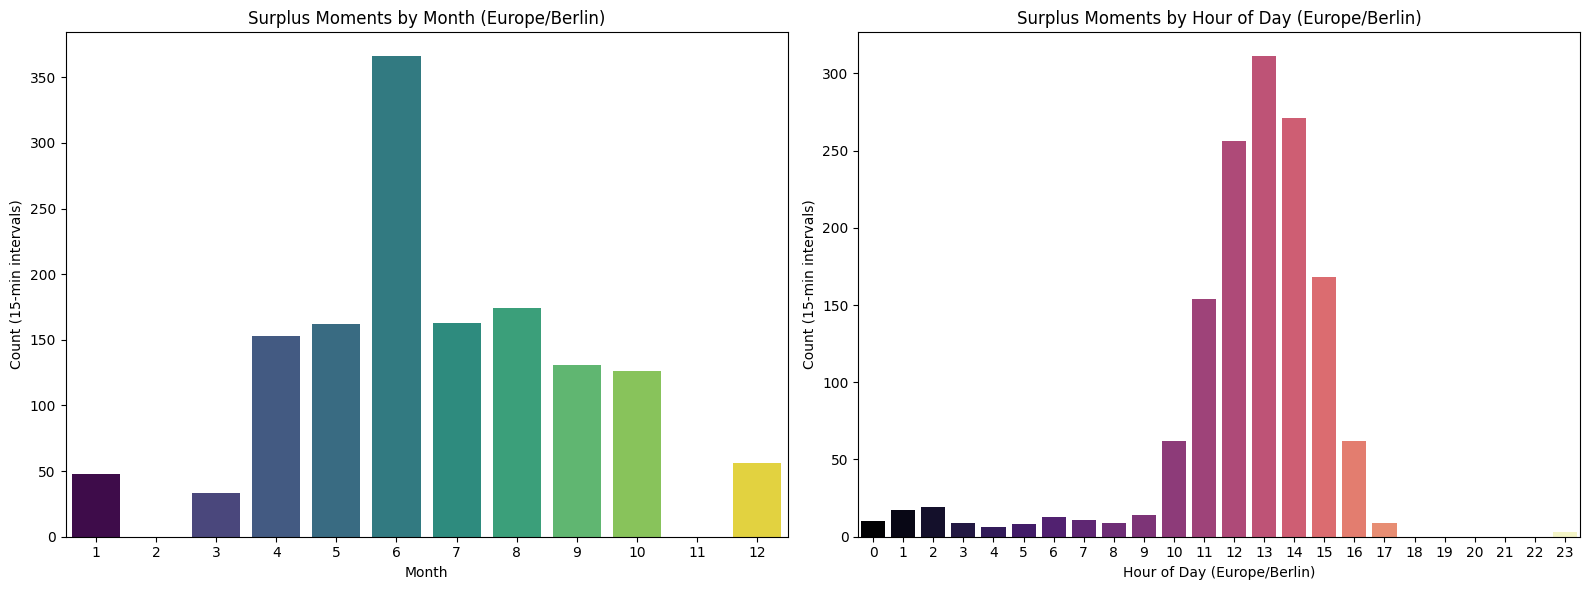

In [14]:
#解决你提到的时区对齐和空缺月份/小时补全的问题，我们需要这个函数做三件事：

#时区转换：将 UTC 转换为 Europe/Berlin。

#全量统计：即便某个月或小时没有数据（Count 为 0），也要显示在坐标轴上。

#格式统一：确保 X 轴的顺序是正确的（1-12 月，0-23 点）

def plot_surplus_distribution(df, timezone='Europe/Berlin'):
    """
    对绿能过剩时刻进行时区转换，并补全缺失的时间段（显示为0）
    """
    # 1. 深度拷贝数据并转换时区
    df_local = df.copy()
    # 确保是本地时间
    df_local['local_time'] = df_local['start_date_utc'].dt.tz_convert(timezone)
    df_local['month'] = df_local['local_time'].dt.month
    df_local['hour'] = df_local['local_time'].dt.hour

    # 2. 准备全量索引 (Reindexing)
    full_months = pd.Index(range(1, 13), name='month')
    full_hours = pd.Index(range(0, 24), name='hour')

    # 3. 计算统计值并补全
    month_counts = df_local['month'].value_counts().reindex(full_months, fill_value=0)
    hour_counts = df_local['hour'].value_counts().reindex(full_hours, fill_value=0)

    # 4. 绘图
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # 图 A：按月份分布
    sns.barplot(x=month_counts.index, y=month_counts.values, ax=ax1, palette='viridis', hue=month_counts.index, legend=False)
    ax1.set_title(f"Surplus Moments by Month ({timezone})")
    ax1.set_xlabel("Month")
    ax1.set_ylabel("Count (15-min intervals)")

    # 图 B：按小时分布
    sns.barplot(x=hour_counts.index, y=hour_counts.values, ax=ax2, palette='magma', hue=hour_counts.index, legend=False)
    ax2.set_title(f"Surplus Moments by Hour of Day ({timezone})")
    ax2.set_xlabel(f"Hour of Day ({timezone})")
    ax2.set_ylabel("Count (15-min intervals)")

    plt.tight_layout()
    plt.show()

# 使用方法：
plot_surplus_distribution(super_green_moments)

In [15]:
# 诊断：检查缺失月份和小时（UTC 与 柏林本地时间）
month_counts_utc = super_green_moments['start_date_utc'].dt.month.value_counts().sort_index()
hour_counts_utc = super_green_moments['start_date_utc'].dt.hour.value_counts().sort_index()

all_months = pd.Index(range(1, 13), name='month')
all_hours = pd.Index(range(0, 24), name='hour')

print('UTC 月份计数（补零后）:')
print(month_counts_utc.reindex(all_months, fill_value=0))
print('\nUTC 小时计数（补零后）:')
print(hour_counts_utc.reindex(all_hours, fill_value=0))

# 转为柏林时间再统计（更符合直觉）
berlin_time = super_green_moments['start_date_utc'].dt.tz_convert('Europe/Berlin')
month_counts_berlin = berlin_time.dt.month.value_counts().sort_index()
hour_counts_berlin = berlin_time.dt.hour.value_counts().sort_index()

print('\n柏林时间 月份计数（补零后）:')
print(month_counts_berlin.reindex(all_months, fill_value=0))
print('\n柏林时间 小时计数（补零后）:')
print(hour_counts_berlin.reindex(all_hours, fill_value=0))

UTC 月份计数（补零后）:
month
1      48
2       0
3      33
4     153
5     162
6     366
7     163
8     174
9     131
10    126
11      0
12     56
Name: count, dtype: int64

UTC 小时计数（补零后）:
hour
0      16
1      19
2       9
3       6
4      10
5      15
6       8
7      14
8      61
9     150
10    249
11    312
12    282
13    173
14     65
15      9
16      0
17      0
18      0
19      0
20      0
21      0
22      3
23     11
Name: count, dtype: int64

柏林时间 月份计数（补零后）:
month
1      48
2       0
3      33
4     153
5     162
6     366
7     163
8     174
9     131
10    126
11      0
12     56
Name: count, dtype: int64

柏林时间 小时计数（补零后）:
hour
0      10
1      17
2      19
3       9
4       6
5       8
6      13
7      11
8       9
9      14
10     62
11    154
12    256
13    311
14    271
15    168
16     62
17      9
18      0
19      0
20      0
21      0
22      0
23      3
Name: count, dtype: int64


In [16]:
# 找到光伏占比最高的那一行
king_moment = df_all.loc[df_all['re_share'].idxmax()]
king_day = king_moment['start_date_utc'].strftime('%Y-%m-%d')

print(f"德国能源转型的‘名场面’发生在：{king_day}")
print(f"那时刻的绿色能源占比达到了：{king_moment['re_share']*100:.2f}%")

德国能源转型的‘名场面’发生在：2024-05-01
那时刻的绿色能源占比达到了：121.64%


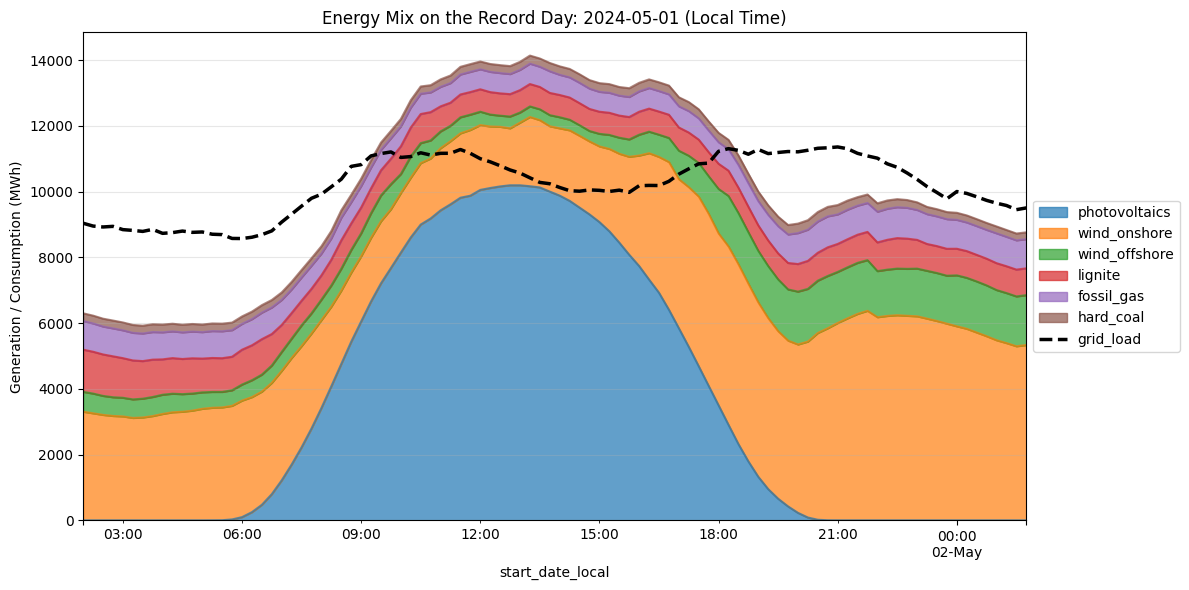

In [17]:
# 1. 确定日期并提取全天数据
target_day = king_moment['start_date_utc'].date()
df_day = df_all[df_all['start_date_utc'].dt.date == target_day].copy()

# 2. 转换时区以便于展示（从 UTC 转回 Europe/Berlin），去掉 tz 避免 matplotlib 坐标冲突
df_day['start_date_local'] = df_day['start_date_utc'].dt.tz_convert('Europe/Berlin').dt.tz_localize(None)

# 3. 准备绘图数据（把 grid_load 一起放进来，后面用 pandas plot 统一渲染）
plot_cols = ['photovoltaics', 'wind_onshore', 'wind_offshore', 'lignite', 'fossil_gas', 'hard_coal']
df_indexed = df_day.set_index('start_date_local')

# 4. 绘图
fig, ax = plt.subplots(figsize=(12, 6))

# area 堆叠图（使用 pandas plot）
df_indexed[plot_cols].plot.area(ax=ax, alpha=0.7, stacked=True)

# 黑色虚线（同样用 pandas plot，避免 matplotlib 转换器冲突）
df_indexed[['grid_load']].plot(ax=ax, color='black', linewidth=2.5,
                                linestyle='--', label='Total Grid Load', zorder=10)

ax.set_title(f"Energy Mix on the Record Day: {king_day} (Local Time)")
ax.set_ylabel("Generation / Consumption (MWh)")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# 算出这一天中，“黑线以上”的面积到底有多大吗？这代表了那一天的总出口电量 (Theoretical Export)
# 计算总发电量
df_day['total_gen'] = df_day[plot_cols].sum(axis=1)

# 计算出口量（只取正值）
df_day['surplus_export'] = (df_day['total_gen'] - df_day['grid_load']).clip(lower=0)

# 计算这一天的总出口量 (MWh) - 注意：每行是 15 分钟，所以要除以 4
total_export_mwh = df_day['surplus_export'].sum() / 4
print(f"这一天德国向邻国‘白送’（或廉价出口）了约 {total_export_mwh:,.2f} MWh 的电量。")

这一天德国向邻国‘白送’（或廉价出口）了约 23,052.88 MWh 的电量。
